In [ ]:
#imports
import sys
import os
package_path = os.path.abspath("..")
sys.path.insert(0, package_path)
#The path will be managed by conda or whatever on release, but this is fine for now.
import pandas as pd
import numpy as np
import time
import pickle

from dask.distributed import Client, LocalCluster
from formulaic import Formula

from scipy.stats import linregress

from tensorzinb.tensorzinb import TensorZINB

import scMPRAforge as scm


In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
cluster=LocalCluster()
client = Client(cluster,
    timeout=f"{5*60}s",   # Client <-> scheduler timeout 
    heartbeat_interval="20s"  # Worker heartbeat interval
)

In [21]:
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
shendure=scm.scMPRA_data.from_tsv(f"{data_root}/shendure/shendure_counts_grouped.txt")

scMPRAforge: INFO: Dropping cell-types & cres with below 3 (MIN_PTS) observations: f{'cre_id': ['Col1a1_chr11_15306', 'Col1a2_chr6_65', 'minP_w_20bp_buffer'], 'cell_type': []}
scMPRAforge: INFO: Dropping 4990 cells with no MPRA UMIs, leaving 38457.


In [22]:
shendure.set_negative_controls(["minP","noP"])

In [23]:
def tensorzinb_fit(matricies):
    """
    Takes matricies as returned by `create_matricies` & produces a tensorzinb model
    """

    

    zinbo = TensorZINB(endog=matricies["regressand"]["umis_mpra_bc"].to_numpy().reshape((-1, 1)),
                       exog=matricies["nb_regressors"].to_numpy(),
                       exog_infl=matricies["zi_regressors"].to_numpy(),)
                       #exog_c=matricies["shared_regressors"],
                       #exog_infl_c=matricies["shared_regressors"])  # ,same_dispersion=True
    zinb_result = None
    try:
        zinb_result = zinbo.fit(init_method="nb")
    except pd.errors.InvalidIndexError:
        return "index_error"

    return zinb_result

def create_matricies(nb_formula,zi_formula,scmpra):
    """
    Takes a scMPRA_data object & formulas & produces design matricies. 
    """
    data=scmpra
    y, X=Formula(nb_formula).get_model_matrix(data,output='pandas')
    Z=Formula(zi_formula).get_model_matrix(data,output='pandas')
    return {
        'nb_regressors':X,
        'regressand':y,
        'zi_regressors':Z
    }

In [27]:
first_time=False

if first_time:
    QC={}
    #loop through all cell-types, produce 
    for cell_type in shendure.data["cell_type"].unique():
        print(cell_type)

        #subset to current cell-type
        shendure_subset=shendure.data[shendure.data["cell_type"]==cell_type]

        #create design matricies
        matricies=create_matricies(nb_formula="umis_mpra_bc ~ C(cre_id, contr.treatment(base='negative_control'))",
                            zi_formula="C(rep_id)-1",
                            scmpra=shendure_subset)
        
        #take the mean for comparison
        shendure_mean=shendure_subset.groupby("cre_id")["umis_mpra_bc"].agg("mean").sort_values()

        #fit a model
        model=tensorzinb_fit(matricies)

        if model=="index_error":
            print("index error")
            continue

        #compute predictions of mu from the model
        linear_mu=matricies["nb_regressors"].to_numpy() @ model["weights"]["x_mu"]
        mu_predictions=np.exp(linear_mu)

        #compute predictions of ZI from the model
        #linear_zi=(matricies["zi_regressors"].to_numpy() @ model["weights"]["x_pi"])
        #zi_predictions=linear_zi=1/(1+np.exp(-linear_zi))

        #get the names of the CREs 
        cre_labeling=scm.undo_one_hot_encoding(matricies["nb_regressors"])["cre_id, contr.treatment(base='negative_control')"]
        cre_labeling=cre_labeling.str.removeprefix("T.")

        #label the predictions with CRE names
        mu_predictions_df=pd.DataFrame({'cre_id':cre_labeling,'mu':mu_predictions.squeeze()})
        mu_predictions_df.sort_values(by='mu')

        #merge means & predicted mu into one df for convienient plotting
        mu_summary=mu_predictions_df.groupby("cre_id").agg("mean")
        mu_summary = mu_summary.merge(shendure_mean.rename_axis('cre_id').reset_index(), on='cre_id', how='left')
        
        ### Computing... ###
        
        x = mu_summary["umis_mpra_bc"]
        y = mu_summary["mu"]

        # Fit regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)

        #store regression info
        ret={'x':x,
            'y':y,
            'slope':slope,
            'intercept':intercept,
            'r_value':r_value,
            'p_value':p_value,
            'std_err':std_err
        }
        
        QC[cell_type]=ret
    with open(f"{data_root}/shendure/cache.pkl","wb") as f:
        pickle.dump(QC,f)
else:
    #not first time
    with open(f"{data_root}/shendure/cache.pkl","rb") as f:
        QC=pickle.load(f)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Plot
    sns.regplot(x=x, y=y, scatter=True, line_kws={"color": "red"})
    plt.text(
        35, 300,  # coordinates for text box
        f"Slope: {slope:.2f}\n$R^2$: {r_value**2:.2f}",
        fontsize=12, bbox=dict(facecolor='white', alpha=0.5)
    )

    plt.show()

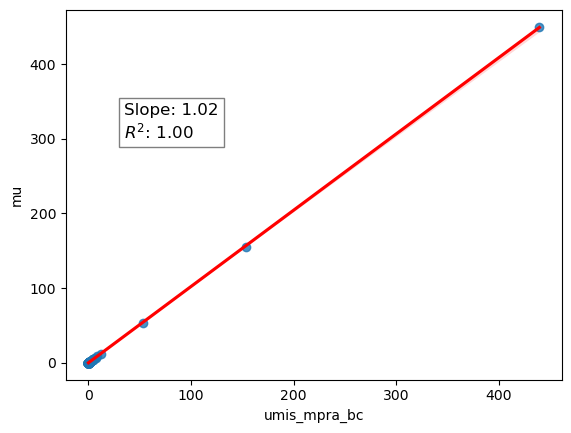

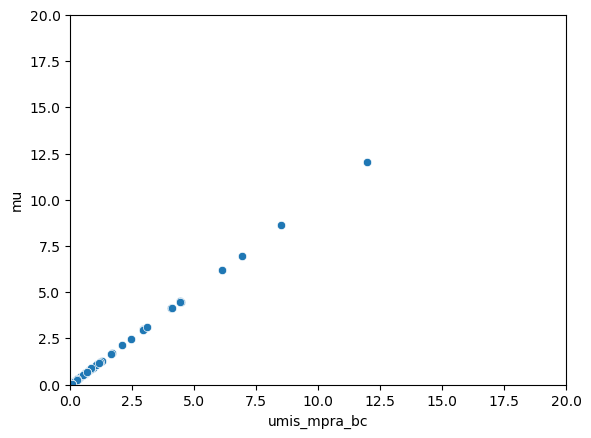

In [28]:
sns.scatterplot(mu_summary,x="umis_mpra_bc",y="mu")
plt.xlim(0, 20)   # Set x-axis limits
plt.ylim(0, 20)   # Set y-axis limits
plt.show()

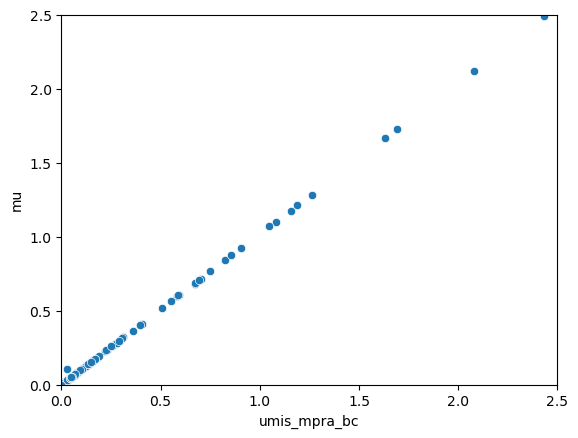

In [29]:
sns.scatterplot(mu_summary,x="umis_mpra_bc",y="mu")
plt.xlim(0, 2.5)   # Set x-axis limits
plt.ylim(0, 2.5)   # Set y-axis limits
plt.show()

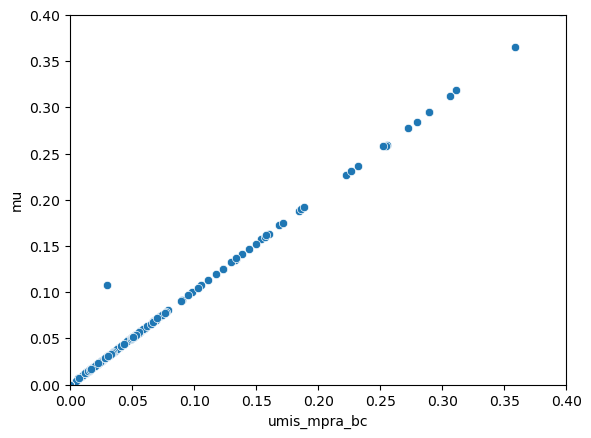

In [30]:
sns.scatterplot(mu_summary,x="umis_mpra_bc",y="mu")
plt.xlim(0, 0.4)   # Set x-axis limits
plt.ylim(0, 0.4)   # Set y-axis limits
plt.show()

In [31]:
replicate_labeling=scm.undo_one_hot_encoding(matricies["zi_regressors"])["rep_id"]
replicate_labeling=replicate_labeling.str.removeprefix("T.")
zi_predictions_df=pd.DataFrame({'rep_id':replicate_labeling,'zi':zi_predictions.squeeze()})
zi_summary=zi_predictions_df.groupby("rep_id").agg("mean")
zi_summary



,zi
rep_id,
2B1,0.015340
2B2,0.010491
A1,0.028121
A2,0.037898
B1,0.018190
B2,0.011061


------

In [70]:
#dat=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres.tsv")
#primordial=scm.ortho()
#primordial.criss_cross(client=client,dat=dat)
#primordial.extract_params(client)

In [71]:
#primordial.by_cell_type_parameters.result().theta

In [19]:
cluster.close()